## Bu projede 5 ayri cesit princ sinifini modele ogretip sonra da tahmin eden bir model gelistirecegiz.

In [1]:
import os
os.listdir("Rice_Image_Dataset")

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

In [2]:
import tensorflow as tf

IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

# SAFE cache + prefetch
train_ds = train_ds.cache("train_cache").prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache("val_cache").prefetch(tf.data.AUTOTUNE)


Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


##### Model

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D,
    Dense, Dropout
)

model = Sequential()

# Input
model.add(Input(shape=(128, 128, 3)))

# -------- BLOCK 1 --------
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- BLOCK 2 --------
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- BLOCK 3 --------
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- CLASSIFIER --------
model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))


##### Early Stopping

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


##### Compile

In [5]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##### Training

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,                
    callbacks=[early_stop]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 560s 297ms/step - accuracy: 0.8167 - loss: 0.4568 - val_accuracy: 0.9319 - val_loss: 0.1870
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 384s 205ms/step - accuracy: 0.9343 - loss: 0.1900 - val_accuracy: 0.9475 - val_loss: 0.1435
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 374s 200ms/step - accuracy: 0.9473 - loss: 0.1533 - val_accuracy: 0.9737 - val_loss: 0.0731
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 398s 212ms/step - accuracy: 0.9592 - loss: 0.1191 - val_accuracy: 0.9100 - val_loss: 0.2595
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 400s 213ms/step - accuracy: 0.9650 - loss: 0.1063 - val_accuracy: 0.9377 - val_loss: 0.1619


In [8]:
model.save('rice_varieties.keras')

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 305,489 (1.17 MB)

 Trainable params: 101,829 (397.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,660 (795.55 KB)

#### Transfer Learning

In [10]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [11]:
# ---------------------------
# Data (TL)
# ---------------------------
IMG_SIZE = (160, 160)   # hızlı + yeterli detay (istersen 170,170 yap)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)


Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


In [12]:
# VGG16 preprocess (RGB -> BGR + mean subtraction)
train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))

# SAFE disk cache + prefetch
train_ds = train_ds.cache("tl_train_cache").prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache("tl_val_cache").prefetch(tf.data.AUTOTUNE)

In [13]:
# ---------------------------
# Model (VGG16 Transfer Learning)
# ---------------------------
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # freeze

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(5, activation="softmax")
])

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),  # TL için düşük LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history_tl = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
 718/1875 ━━━━━━━━━━━━━━━━━━━━ 38:59 2s/step - accuracy: 0.5457 - loss: 2.3418

KeyboardInterrupt: 

 Burada VGG16 tabanli model egitimi saatlerce surecek cok uzun bir yola soktu bizi, bu sekilde devam edemeyecegimize karar verdik ve modelimizi degistirdik.

##### MobileNetV2

In [16]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (128, 128)   # küçük + hızlı
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Rice_Image_Dataset",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

# MobileNet preprocess
train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))

# SAFE cache
train_ds = train_ds.cache("mb_train_cache").prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache("mb_val_cache").prefetch(tf.data.AUTOTUNE)


Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


##### Model

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False  # gerçek TL

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),  # MobileNet bunu kaldırır
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step 


##### Training

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop]
)


Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 662s 350ms/step - accuracy: 0.9794 - loss: 0.0621 - val_accuracy: 0.9921 - val_loss: 0.0233
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 415s 221ms/step - accuracy: 0.9890 - loss: 0.0339 - val_accuracy: 0.9931 - val_loss: 0.0225
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 442s 236ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9941 - val_loss: 0.0202
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 508s 271ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.9941 - val_loss: 0.0198
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.9924 - loss: 0.0239 - val_accuracy: 0.9931 - val_loss: 0.0217
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 391s 209ms/step - accuracy: 0.9923 - loss: 0.0227 - val_accuracy: 0.9942 - val_loss: 0.0187
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 449s 240ms/step - accuracy: 0.9937 - loss: 0.0205 - val_accuracy: 0.9941 - val_loss: 0.0222
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 489s 261ms/step - accuracy: 

In [19]:
model.save("rice_vgg16_transfer.keras")

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,504,913 (9.56 MB)

 Trainable params: 82,309 (321.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,620 (643.05 KB)

##### Visualization

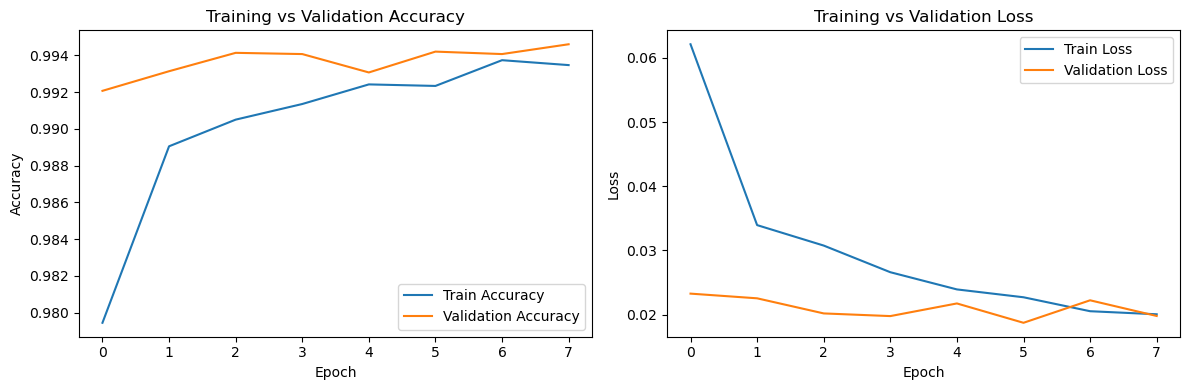

In [25]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

tf.data.Dataset’te label’lar dataset’in içindedir, attribute olarak değil.

O yuzden burada daha once kurguladigim yolu degistiyorum.

In [28]:
# Generator sırasını bozma
# val_ds.reset()

# Tahmin olasılıkları
# y_pred_probs = model.predict(val_ds, verbose=1)

# Olasılıktan sınıf index'i
# y_pred = np.argmax(y_pred_probs, axis=1)

# GERÇEK label'lar (sparse olduğu için direkt alınır)
# y_true = val_ds.classes # bunu da calistiramadik.

In [37]:
# Gerçek label'lar (val_ds içinden)

y_true = np.concatenate([
    y.numpy() for _, y in val_ds
])



y_pred_probs = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step


##### Class_names

In [30]:
# class_names = list(val_ds.class_indices.keys())
# ayni sekilde yukaridaki kodu da calistiramayiz, onun yerine asagida yeni kurgu ile cozeriz.

In [38]:
# class_names = val_ds.class_names
# bu da hata verdi. __PrefetchDataset' object has no attribute 'class_names' hatasi verdi.

Class_names icin yeni tanimlama

In [39]:
data_dir="Rice_Image_Dataset"

In [40]:
class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])
print("Class names:", class_names)

Class names: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


##### Confusion matrix

In [41]:
cm = confusion_matrix(y_true, y_pred)

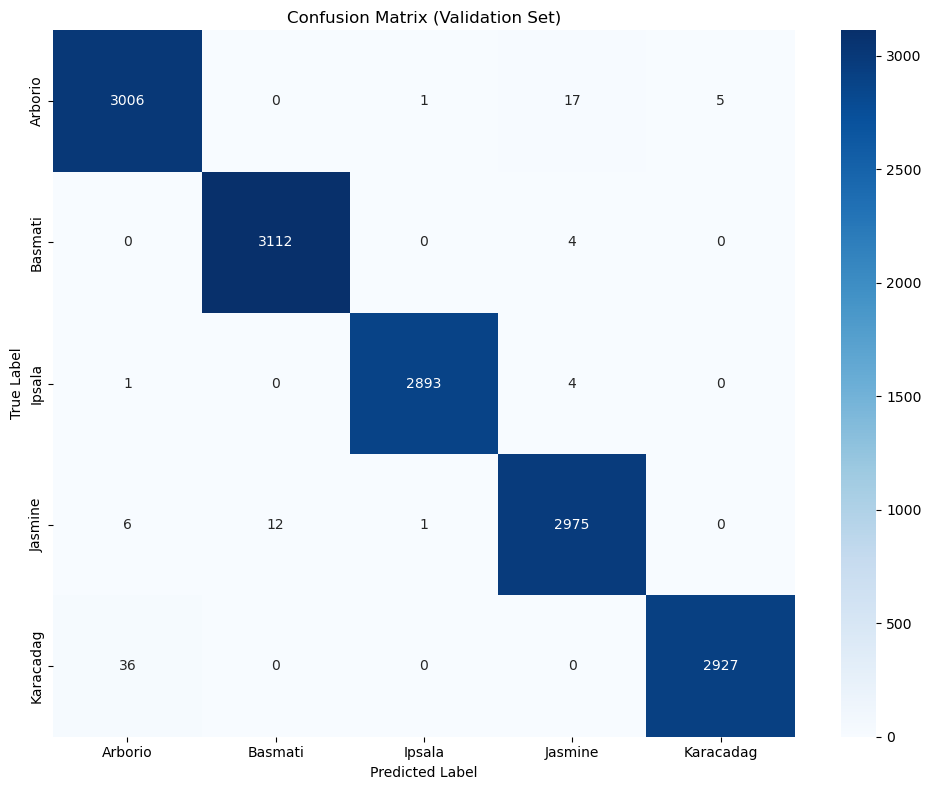

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

##### Classification Report

In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99      3029
     Basmati       1.00      1.00      1.00      3116
      Ipsala       1.00      1.00      1.00      2898
     Jasmine       0.99      0.99      0.99      2994
   Karacadag       1.00      0.99      0.99      2963

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



In [44]:
import pandas as pd

pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            pairs.append({
                "Gerçek Sınıf": class_names[i],
                "Tahmin Edilen": class_names[j],
                "Hata Sayısı": cm[i, j]
            })

df_errors = pd.DataFrame(pairs)
df_errors = df_errors.sort_values(by="Hata Sayısı", ascending=False)

df_errors.head(10)

,Gerçek Sınıf,Tahmin Edilen,Hata Sayısı
9,Karacadag,Arborio,36
1,Arborio,Jasmine,17
7,Jasmine,Basmati,12
6,Jasmine,Arborio,6
2,Arborio,Karacadag,5
3,Basmati,Jasmine,4
5,Ipsala,Jasmine,4
0,Arborio,Ipsala,1
4,Ipsala,Arborio,1
8,Jasmine,Ipsala,1


## Conclusion

Bu calismada hem kendi cnn modelimizle, hem de daha onceden ogretilmis olan MobileNetV2 Transfer Learning metodu ile modellerimiz egitilmis olup, iki model de basarili sonuclar vermis olup ozellikle TL modeli ust seviye performans gostererek tum siniflari buyuk basari ile cozumlemistir. Calisma basari ile neticelendirildikten sonra HF uygulamasi uzerinden streamlit uzantili bir tahmin ekrani uzerinden kullanicilarin deneyimine sunulmustur.